# 02. Limpieza y Enriquecimiento de Datos (Feature Engineering)

Una vez que entendieron los datos, vamos a prepararlos para que los algoritmos de Machine Learning puedan procesarlos correctamente. En la vida real, lo mejor es empaquetar esto automatizado en Scikit-Learn Pipelines o en scripts de Python (`src/features/build_features.py`). Aquí puedes experimentar con las rutinas de limpieza.

### Instrucciones Generales:
1. **Solvertar problema de calidad:**: Solucionar problema de calidad encontrados en el EDA: consistencia, sensibilidad, precision y completitud. Documenta cada decision tomada.
2. **Codificación Categórica:** El campo `ocean_proximity` es de texto. Conviértelo en variable numerica, ya que los algoritmos clasicos no entienen el texto. Documenta porque usaste codificacion Ordinal o Nominal.
3. **Enriquecimiento (Feature Engineering):** Como pudiste notar en tu análisis, `total_rooms` no significa mucho si hay muchos hogares en un distrito. Agrega nuevas métricas útiles, por ejemplo:
   - `rooms_per_household = total_rooms / households`
   - `bedrooms_per_room = total_bedrooms / total_rooms`
   - `population_per_household = population / households`
4. **Escalado de Variables:** Aplica un `StandardScaler` o `MinMaxScaler` para evitar que las variables numéricas grandes pesen más en algoritmos basados en distancias o gradientes.


In [ ]:
# # 02. Limpieza y Enriquecimiento de Datos (Feature Engineering)
#
# En esta etapa se prepara el conjunto de datos para su uso en algoritmos de Machine Learning.
# El objetivo no es únicamente "limpiar" la base, sino también transformarla de manera que
# represente mejor la estructura real del problema de negocio.
#
# A partir de los hallazgos del EDA, se abordarán cuatro frentes:
#
# 1. Tratamiento de problemas de calidad de datos
# 2. Codificación de la variable categórica `ocean_proximity`
# 3. Ingeniería de variables (feature engineering)
# 4. Escalado de variables numéricas
#
# Además, se documentará cada decisión metodológica indicando qué se hizo y por qué se hizo.



In [24]:
# =========================================================
# 1. LIBRERÍAS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ## 1. Carga de datos
#
# Para evitar fuga de datos (data leakage), todo el proceso de limpieza y transformación
# se realiza únicamente sobre el conjunto de entrenamiento.
#
# La variable objetivo (`median_house_value`) se separa del resto de variables explicativas
# para mantener una estructura adecuada de modelado supervisado.



# %%
# =========================================================
# 2. CARGA DE DATOS Y SEPARACIÓN X / y
# =========================================================

train = pd.read_csv("../data/interim/train_set.csv")

X = train.drop("median_house_value", axis=1).copy()
y = train["median_house_value"].copy()

print("Shape original de X:", X.shape)
print("Shape de y:", y.shape)

display(X.head())


Shape original de X: (16512, 9)
Shape de y: (16512,)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY
1,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN
2,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND
3,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND
4,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN


In [ ]:
# ## 2. Diagnóstico inicial de calidad de datos
#
# Antes de transformar los datos, se revisa la estructura general del dataset para identificar:

# - tipos de variables,
# - valores faltantes,
# - distribución de la variable categórica,
# - posibles problemas de calidad que deban resolverse.
#
# Esta etapa es clave porque permite justificar técnicamente las decisiones posteriores.

In [26]:
# =========================================================
# 3. DIAGNÓSTICO INICIAL
# =========================================================

print("Tipos de datos:")
display(X.dtypes)

print("Valores faltantes por variable:")
display(X.isnull().sum().sort_values(ascending=False))

print("Distribución de la variable categórica ocean_proximity:")
display(X["ocean_proximity"].value_counts(dropna=False))

Tipos de datos:


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
ocean_proximity        object
dtype: object

Valores faltantes por variable:


total_bedrooms        168
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

Distribución de la variable categórica ocean_proximity:


ocean_proximity
<1H OCEAN     7274
INLAND        5301
NEAR OCEAN    2089
NEAR BAY      1846
ISLAND           2
Name: count, dtype: int64

### 3. Evaluación de calidad de datos
A partir del diagnóstico inicial y del EDA realizado previamente, se identifican los siguientes criterios:
#### 3.1 Completitud
Se detectó que la variable `total_bedrooms` presenta valores faltantes. Este problema debe corregirse
para que los algoritmos puedan procesar correctamente el dataset.
#### 3.2 Consistencia
No se observan categorías inválidas ni formatos mixtos en la variable `ocean_proximity`.
Las variables numéricas presentan tipos consistentes.
#### 3.3 Sensibilidad
Variables como `total_rooms`, `population`, `households` y `total_bedrooms` presentan asimetría
y valores extremos, por lo que conviene considerar medidas robustas de imputación y transformaciones.
#### 3.4 Precisión
 No se identifican errores evidentes de medición, pero sí se observó que algunas variables absolutas
 no representan adecuadamente el fenómeno. Por ello, se crearán métricas relativas que capturen
 mejor la estructura real del distrito.

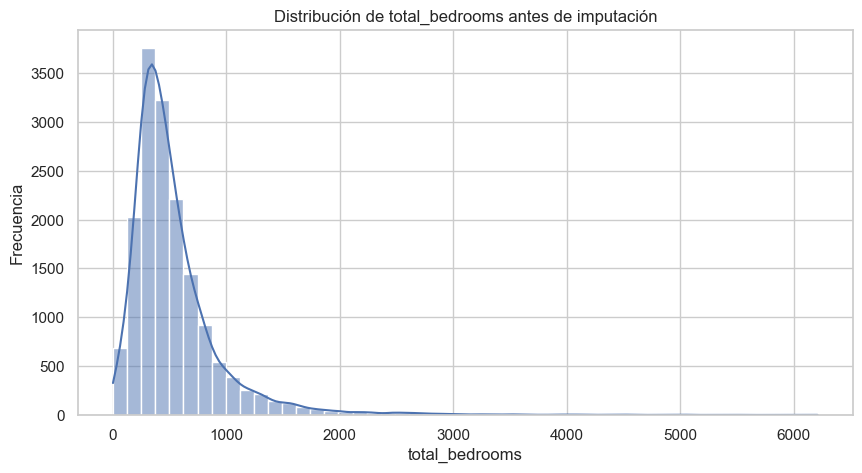

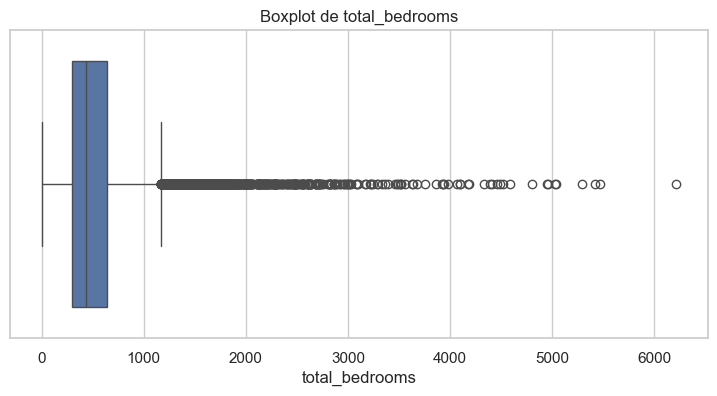

In [27]:
# ## 4. Análisis específico de la variable con faltantes
#
# Antes de imputar, es importante revisar la forma de la distribución de `total_bedrooms`.
# Esto permite decidir si conviene utilizar la media o la mediana.
#
# Dado que durante el EDA se identificó asimetría y presencia de outliers, la mediana será una
# alternativa más robusta que la media.

# %%
# =========================================================
# 4. ANÁLISIS DE LA VARIABLE CON FALTANTES
# =========================================================

plt.figure(figsize=(10, 5))
sns.histplot(X["total_bedrooms"], bins=50, kde=True)
plt.title("Distribución de total_bedrooms antes de imputación")
plt.xlabel("total_bedrooms")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(x=X["total_bedrooms"])
plt.title("Boxplot de total_bedrooms")
plt.show()

In [28]:
# ## 5. Imputación de valores faltantes
#
# ### ¿Qué se hizo?
# Se imputaron los valores faltantes de las variables numéricas utilizando la **mediana**.
#
# ### ¿Por qué se hizo?
# La mediana es una medida robusta frente a distribuciones asimétricas y valores atípicos.
# Dado que `total_bedrooms` presenta estas características, la imputación por mediana resulta
# metodológicamente más adecuada que la imputación por media.
#
# ### ¿Por qué no se eliminaron registros?
# Porque la proporción de faltantes es baja y eliminar observaciones implicaría pérdida innecesaria
# de información valiosa para el entrenamiento del modelo.
#
# ### Nota metodológica
# En este notebook se realiza una imputación explícita para poder inspeccionar y analizar
# las variables derivadas. Más adelante, en la fase de producción, esta lógica se trasladará
# a un script reusable en `src/features/build_features.py`.

In [29]:
# =========================================================
# 5. IMPUTACIÓN DE VARIABLES NUMÉRICAS
# =========================================================

num_cols_original = X.drop(columns=["ocean_proximity"]).columns.tolist()
cat_cols = ["ocean_proximity"]

imputer = SimpleImputer(strategy="median")

X_num_imputed = pd.DataFrame(
    imputer.fit_transform(X[num_cols_original]),
    columns=num_cols_original,
    index=X.index
)

X_clean = pd.concat([X_num_imputed, X[cat_cols]], axis=1)

print("Shape después de imputación:", X_clean.shape)
print("Valores faltantes después de imputación:")
display(X_clean.isnull().sum().sort_values(ascending=False))

Shape después de imputación: (16512, 9)
Valores faltantes después de imputación:


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [31]:
# ## 6. Ingeniería de variables
#
# Una vez resuelto el problema de completitud, se procede al enriquecimiento del dataset mediante
# la creación de variables derivadas.
#
# ### ¿Qué se hizo?
# Se generaron métricas relativas y transformaciones no lineales a partir de variables existentes.
#
# ### ¿Por qué se hizo?
# Porque variables absolutas como `total_rooms` o `population` no son suficientemente informativas
# por sí solas. Por ejemplo, 10,000 habitaciones pueden significar algo muy distinto dependiendo
# del número de hogares o de personas en el distrito.
#
# Por ello, se construyen variables que capturan:
#
# - densidad habitacional,
# - hacinamiento,
# - disponibilidad de espacio,
# - capacidad económica relativa,
# - patrones espaciales,
# - corrección de asimetría mediante transformaciones logarítmicas.
#
#
# En futuras iteraciones se podrá analizar la posibilidad de incorporar otras variables derivadas
# que representen mejor el contexto geográfico, demográfico o económico del distrito.

In [32]:
# =========================================================
# 6. FEATURE ENGINEERING
# =========================================================

def add_features(df):
    df = df.copy()
    eps = 1e-6  # para evitar divisiones por cero

    # -----------------------------------------
    # Variables creadas principales
    # -----------------------------------------
    df["rooms_per_household"] = df["total_rooms"] / (df["households"] + eps)
    df["bedrooms_per_room"] = df["total_bedrooms"] / (df["total_rooms"] + eps)
    df["population_per_household"] = df["population"] / (df["households"] + eps)

    # -----------------------------------------
    # Variables adicionales útiles
    # -----------------------------------------
    df["bedrooms_per_household"] = df["total_bedrooms"] / (df["households"] + eps)
    df["rooms_per_person"] = df["total_rooms"] / (df["population"] + eps)

    # Interacción geográfica
    df["geo_interaction"] = df["latitude"] * df["longitude"]

    # -----------------------------------------
    # Transformaciones logarítmicas
    # -----------------------------------------
    df["log_total_rooms"] = np.log1p(df["total_rooms"])
    df["log_total_bedrooms"] = np.log1p(df["total_bedrooms"])
    df["log_population"] = np.log1p(df["population"])
    df["log_households"] = np.log1p(df["households"])
    df["log_median_income"] = np.log1p(df["median_income"])

    return df

X_fe = add_features(X_clean)

print("Shape antes del feature engineering:", X_clean.shape)
print("Shape después del feature engineering:", X_fe.shape)

new_cols = [col for col in X_fe.columns if col not in X_clean.columns]

print("Nuevas variables creadas:")
for col in new_cols:
    print("-", col)

Shape antes del feature engineering: (16512, 9)
Shape después del feature engineering: (16512, 20)
Nuevas variables creadas:
- rooms_per_household
- bedrooms_per_room
- population_per_household
- bedrooms_per_household
- rooms_per_person
- geo_interaction
- log_total_rooms
- log_total_bedrooms
- log_population
- log_households
- log_median_income


### 7. Justificación de las variables derivadas
A continuación se resume el propósito de cada grupo de variables creadas:
#### Variables de densidad habitacional
- `rooms_per_household`: mide el número promedio de habitaciones por hogar.
- `bedrooms_per_room`: mide la proporción de dormitorios sobre el total de habitaciones.
- `population_per_household`: aproxima el tamaño promedio del hogar.
- `bedrooms_per_household`: resume la disponibilidad de dormitorios por hogar.
- `rooms_per_person`: aproxima el espacio disponible por persona.
Estas variables convierten métricas absolutas en indicadores relativos más interpretables.
#### Variable de interacción geográfica
 - `geo_interaction`: combina latitud y longitud para capturar efectos espaciales no lineales.
#### Transformaciones logarítmicas
- `log_total_rooms`
- `log_total_bedrooms`
- `log_population`
- `log_households`
- `log_median_income`
Estas transformaciones se aplican para:
- reducir asimetría,
- mitigar el impacto de outliers,
- estabilizar varianza,
- mejorar la relación funcional con la variable objetivo.
#### Líneas futuras de enriquecimiento
En futuras fases del proyecto se podrá analizar la viabilidad de incorporar nuevas variables relevantes,
por ejemplo:
- distancias geográficas aproximadas a zonas costeras,
- clusters espaciales,
- interacciones entre ingreso y localización,
- transformaciones no lineales adicionales,
- selección automática de variables según importancia predictiva.

In [35]:
# ## 8. Validación preliminar del feature engineering
#
# Crear variables derivadas no garantiza automáticamente una mejora del modelo.
# Por ello, se realiza una validación preliminar mediante correlación con la variable objetivo.
#
# ### ¿Qué se hizo?
# Se calcularon las correlaciones entre las variables numéricas y `median_house_value`.
#
# ### ¿Por qué se hizo?
# Porque esto permite identificar si las nuevas variables aportan señal útil o si, por el contrario,
# introducen ruido o redundancia innecesaria.
#
# Esta revisión no reemplaza la evaluación final del modelo, pero sí sirve como filtro exploratorio.

In [37]:

# =========================================================
# 8. VALIDACIÓN DE VARIABLES DERIVADAS
# =========================================================

tmp = X_fe.copy()
tmp["median_house_value"] = y

corr_with_target = tmp.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

print("Top 20 variables más correlacionadas con el precio:")
display(corr_with_target.head(20))

Top 20 variables más correlacionadas con el precio:


median_house_value          1.000000
median_income               0.688380
log_median_income           0.669936
rooms_per_person            0.202050
log_total_rooms             0.161577
rooms_per_household         0.143663
total_rooms                 0.137455
housing_median_age          0.102175
geo_interaction             0.099808
log_households              0.076795
households                  0.071426
log_total_bedrooms          0.055574
total_bedrooms              0.054530
log_population             -0.019197
population                 -0.020153
population_per_household   -0.038224
bedrooms_per_household     -0.044391
longitude                  -0.050859
latitude                   -0.139584
bedrooms_per_room          -0.229558
Name: median_house_value, dtype: float64

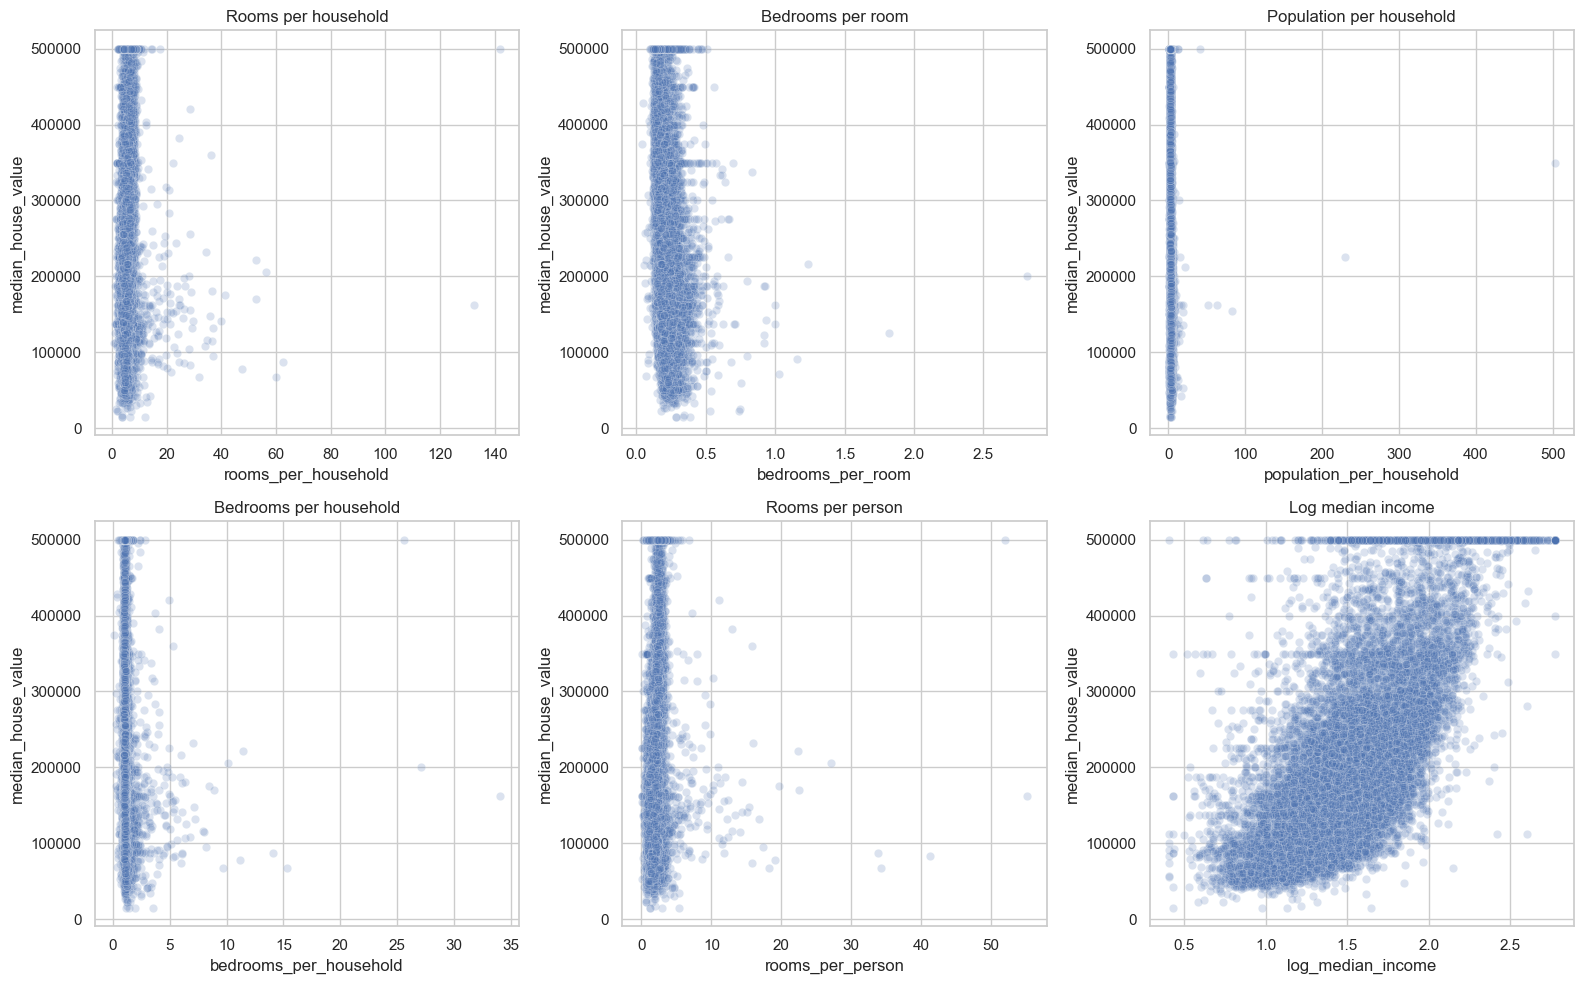

In [38]:
# ## 9. Visualización bivariada de variables derivadas
#
# Además de la correlación numérica, se inspeccionan visualmente algunas relaciones importantes
# para verificar tendencias, dispersión, no linealidades y posibles outliers.
#
# Esto permite validar si las nuevas variables capturan patrones coherentes con el fenómeno económico.



# =========================================================
# 9. VISUALIZACIÓN DE VARIABLES DERIVADAS
# =========================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.scatterplot(data=tmp, x="rooms_per_household", y="median_house_value", alpha=0.2, ax=axes[0, 0])
axes[0, 0].set_title("Rooms per household")

sns.scatterplot(data=tmp, x="bedrooms_per_room", y="median_house_value", alpha=0.2, ax=axes[0, 1])
axes[0, 1].set_title("Bedrooms per room")

sns.scatterplot(data=tmp, x="population_per_household", y="median_house_value", alpha=0.2, ax=axes[0, 2])
axes[0, 2].set_title("Population per household")

sns.scatterplot(data=tmp, x="bedrooms_per_household", y="median_house_value", alpha=0.2, ax=axes[1, 0])
axes[1, 0].set_title("Bedrooms per household")

sns.scatterplot(data=tmp, x="rooms_per_person", y="median_house_value", alpha=0.2, ax=axes[1, 1])
axes[1, 1].set_title("Rooms per person")

sns.scatterplot(data=tmp, x="log_median_income", y="median_house_value", alpha=0.2, ax=axes[1, 2])
axes[1, 2].set_title("Log median income")

plt.tight_layout()
plt.show()

In [39]:
# ## 10. Codificación de la variable categórica
#
# La variable `ocean_proximity` contiene texto, por lo que los modelos clásicos de Machine Learning
# no pueden procesarla directamente.
#
# ### ¿Qué se hizo?
# Se aplicó **One-Hot Encoding**.
#
# ### ¿Por qué se hizo?
# Porque `ocean_proximity` es una variable **nominal**, no ordinal.
# Es decir, sus categorías no tienen un orden natural entre sí.
#
# Por ejemplo, no tendría sentido afirmar que:
#
# - `INLAND = 1`
# - `NEAR BAY = 2`
# - `NEAR OCEAN = 3`
#
# ya que eso introduciría una jerarquía artificial y sesgaría al modelo.
#
# Por ello, One-Hot Encoding es la opción más adecuada, ya que representa cada categoría
# mediante una columna binaria independiente.


# %%
# =========================================================
# 10. DEFINICIÓN DE ATRIBUTOS NUMÉRICOS Y CATEGÓRICOS
# =========================================================

num_attribs = X_fe.drop(columns=["ocean_proximity"]).columns.tolist()
cat_attribs = ["ocean_proximity"]

print("Cantidad de variables numéricas:", len(num_attribs))
print("Variables categóricas:", cat_attribs)


Cantidad de variables numéricas: 19
Variables categóricas: ['ocean_proximity']


In [40]:
# ## 11. Escalado de variables numéricas
#
# Las variables numéricas presentan magnitudes muy distintas entre sí.
# Por ejemplo, `population` puede tener valores mucho mayores que `median_income`.
#
# ### ¿Qué se hizo?
# Se aplicó `StandardScaler` a las variables numéricas.
#
# ### ¿Por qué se hizo?
# Porque muchos algoritmos son sensibles a la escala de las variables,
# especialmente aquellos basados en distancia, gradiente o regularización.
#
# El escalado permite:
#
# - centrar las variables en media 0,
# - estandarizar la desviación a 1,
# - evitar que variables grandes dominen el modelo.



# %%
# =========================================================
# 11. PIPELINE FINAL DE PREPROCESAMIENTO
# =========================================================

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

X_prepared = full_pipeline.fit_transform(X_fe)

print("Shape final transformado:", X_prepared.shape)


Shape final transformado: (16512, 24)


In [41]:

# ## 12. Construcción del dataset final transformado
#
# En esta etapa se reconstruye un DataFrame con los nombres finales de las variables,
# incluyendo tanto las numéricas escaladas como las columnas generadas por One-Hot Encoding.
#
# Esto facilita la inspección, trazabilidad y futura interpretación del modelo.


# =========================================================
# 12. DATAFRAME FINAL TRANSFORMADO
# =========================================================

ohe = full_pipeline.named_transformers_["cat"]["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_attribs)

final_feature_names = num_attribs + list(cat_feature_names)

X_prepared_df = pd.DataFrame(
    X_prepared,
    columns=final_feature_names,
    index=X_fe.index
)

print("Primeras filas del dataset transformado:")
display(X_prepared_df.head())

print("Valores faltantes finales:")
print(X_prepared_df.isnull().sum().sum())

print("Shape final del DataFrame:")
print(X_prepared_df.shape)

Primeras filas del dataset transformado:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,...,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,-0.866027,1.846624,...,0.638538,1.331502,0.457313,1.317893,-1.078547,0.0,0.0,0.0,1.0,0.0
1,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,0.024550,-0.508121,...,-0.064085,-0.255920,-0.713720,-0.144801,1.231761,1.0,0.0,0.0,0.0,0.0
2,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,-0.041193,-0.202155,...,-0.861510,-0.931729,-0.944405,-0.919687,-0.792464,0.0,1.0,0.0,0.0,0.0
3,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,-0.034858,-0.149006,...,0.944663,0.957413,0.671649,0.929933,-0.935308,0.0,1.0,0.0,0.0,0.0
4,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,-0.666554,0.963208,...,1.004887,1.445870,0.720167,1.490342,-0.018667,0.0,0.0,0.0,0.0,1.0


Valores faltantes finales:
0
Shape final del DataFrame:
(16512, 24)



### 14. Conclusión técnica
El proceso de limpieza y feature engineering fue exitoso y metodológicamente consistente con los hallazgos del EDA.
#### Qué se hizo
- Se imputaron valores faltantes con mediana
- Se crearon variables derivadas de densidad, estructura y localización
- Se aplicaron transformaciones logarítmicas en variables sesgadas
- Se codificó `ocean_proximity` mediante One-Hot Encoding
- Se escalaron las variables numéricas con `StandardScaler`
#### Por qué se hizo
- Para resolver problemas de completitud
- Para representar mejor la estructura real del mercado inmobiliario
- Para reducir efectos de asimetría y outliers
- Para hacer el dataset compatible con algoritmos de Machine Learning
- Para mejorar la estabilidad y capacidad predictiva del modelo
#### Consideración futura
En futuras etapas será conveniente analizar la posibilidad de incorporar variables adicionales
que profundicen la representación económica, geográfica y estructural de los distritos,
así como evaluar la importancia real de cada feature dentro de los modelos seleccionados.
En consecuencia, el dataset resultante queda listo para pasar a la fase de experimentación y modelado.